<a href="https://colab.research.google.com/github/zavisk/AutonomousMedicalImage_TriageAgent/blob/main/chexpert_classification_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autonomous Medical Image Triage Agent

**Multi-Label Chest X-Ray Classification using Deep Learning**

This notebook implements pathology detection on the CheXpert dataset, comparing 4 architectures: DenseNet-121, EfficientNet-B0, ResNet-50, and Vision Transformer (ViT-B-16).

| | |
|---|---|
| **Authors** | Vishal Kumar, Deepashree Srinivasa Rao Rannore |
| **Course** | DS 5500 - Data Science Capstone |
| **Institution** | Northeastern University |
| **Dataset** | CheXpert (Stanford ML Group) |

## 1. Environment Setup

In [ ]:
!pip install -q torch torchvision pandas numpy matplotlib seaborn scikit-learn tqdm kaggle

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
from tqdm import tqdm
import json
import os
import warnings

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

In [ ]:
CONFIG = {
    'data_dir': '/content/chexpert/',
    'train_csv': '/content/chexpert/train.csv',
    'valid_csv': '/content/chexpert/valid.csv',
    'output_dir': '/content/drive/MyDrive/chexpert_outputs/',
    'sample_size': None,          # Use FULL dataset (~190K frontal) for best AUC; set to 150000 if GPU time is limited
    'image_size': 256,            # Increased from 224 — better feature resolution for chest X-rays
    'batch_size': 64,
    'num_epochs': 20,             # Increased from 10 — models were still improving at epoch 10
    'learning_rate': 3e-4,        # Slightly higher initial LR works well with cosine schedule
    'weight_decay': 1e-4,         # L2 regularization via AdamW
    'label_smoothing': 0.05,      # Reduces overconfidence on uncertain medical labels
    'num_workers': 4,
    'target_labels': ['Cardiomegaly', 'Pneumonia', 'Pneumothorax', 'Edema', 'Pleural Effusion'],
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)

## 3. Dataset Download

In [ ]:
!mkdir -p ~/.kaggle

kaggle_credentials = {
    "username": "YOUR_KAGGLE_USERNAME",
    "key": "YOUR_KAGGLE_API_KEY"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d ashery/chexpert -p /content/
!unzip -q -o /content/chexpert.zip -d /content/chexpert

Dataset URL: https://www.kaggle.com/datasets/ashery/chexpert
License(s): CC0-1.0
100% 10.7G/10.7G [10:25<00:00, 18.4MB/s]



In [ ]:
!ls -la /content/chexpert/

total 25940
drwxr-xr-x     4 root root     4096 Mar 21 14:07 .
drwxr-xr-x     1 root root     4096 Mar 21 14:05 ..
drwxr-xr-x 64542 root root  2002944 Mar 21 14:07 train
-rw-r--r--     1 root root 24505945 Apr 28  2021 train.csv
drwxr-xr-x   202 root root     4096 Mar 21 14:07 valid
-rw-r--r--     1 root root    32896 Apr 28  2021 valid.csv


## 4. Data Loading

In [ ]:
train_df = pd.read_csv(CONFIG['train_csv'])
valid_df = pd.read_csv(CONFIG['valid_csv'])

print(f"Training samples: {len(train_df):,}")
print(f"Validation samples: {len(valid_df):,}")

Training samples: 223,414
Validation samples: 234


## 5. Exploratory Data Analysis

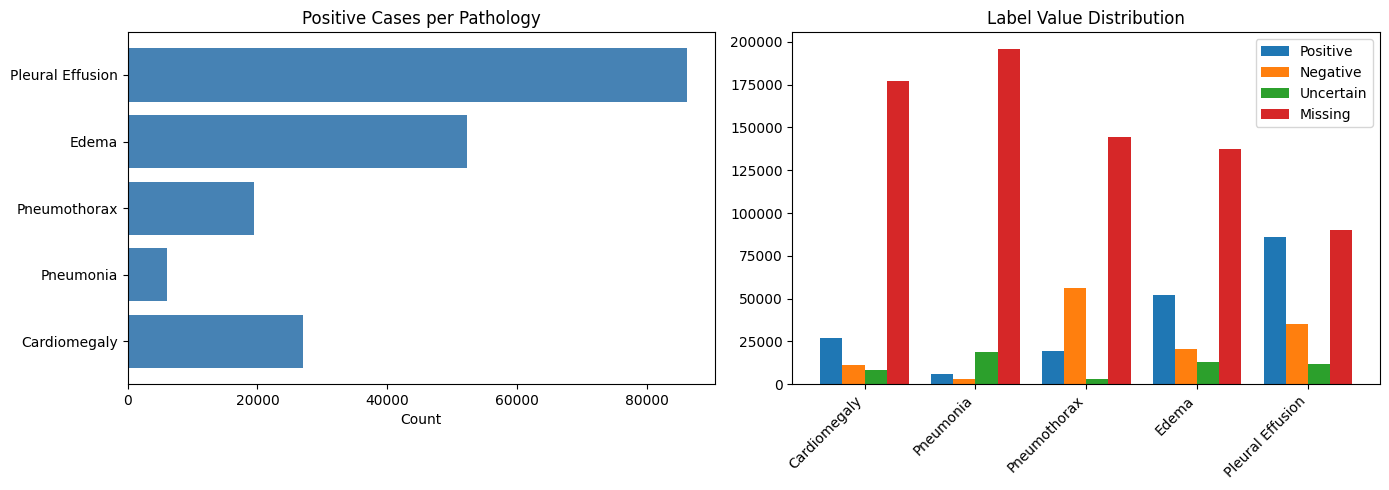

In [ ]:
def plot_label_distribution(df, labels):
    """Visualize pathology label distribution."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    positive_counts = [(df[label] == 1.0).sum() for label in labels]
    axes[0].barh(labels, positive_counts, color='steelblue')
    axes[0].set_xlabel('Count')
    axes[0].set_title('Positive Cases per Pathology')

    value_counts = []
    for label in labels:
        counts = {
            'Positive': (df[label] == 1.0).sum(),
            'Negative': (df[label] == 0.0).sum(),
            'Uncertain': (df[label] == -1.0).sum(),
            'Missing': df[label].isna().sum()
        }
        value_counts.append(counts)

    dist_df = pd.DataFrame(value_counts, index=labels)
    dist_df.plot(kind='bar', ax=axes[1], width=0.8)
    axes[1].set_title('Label Value Distribution')
    axes[1].set_xticklabels(labels, rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}label_distribution.png", dpi=150)
    plt.show()

plot_label_distribution(train_df, CONFIG['target_labels'])

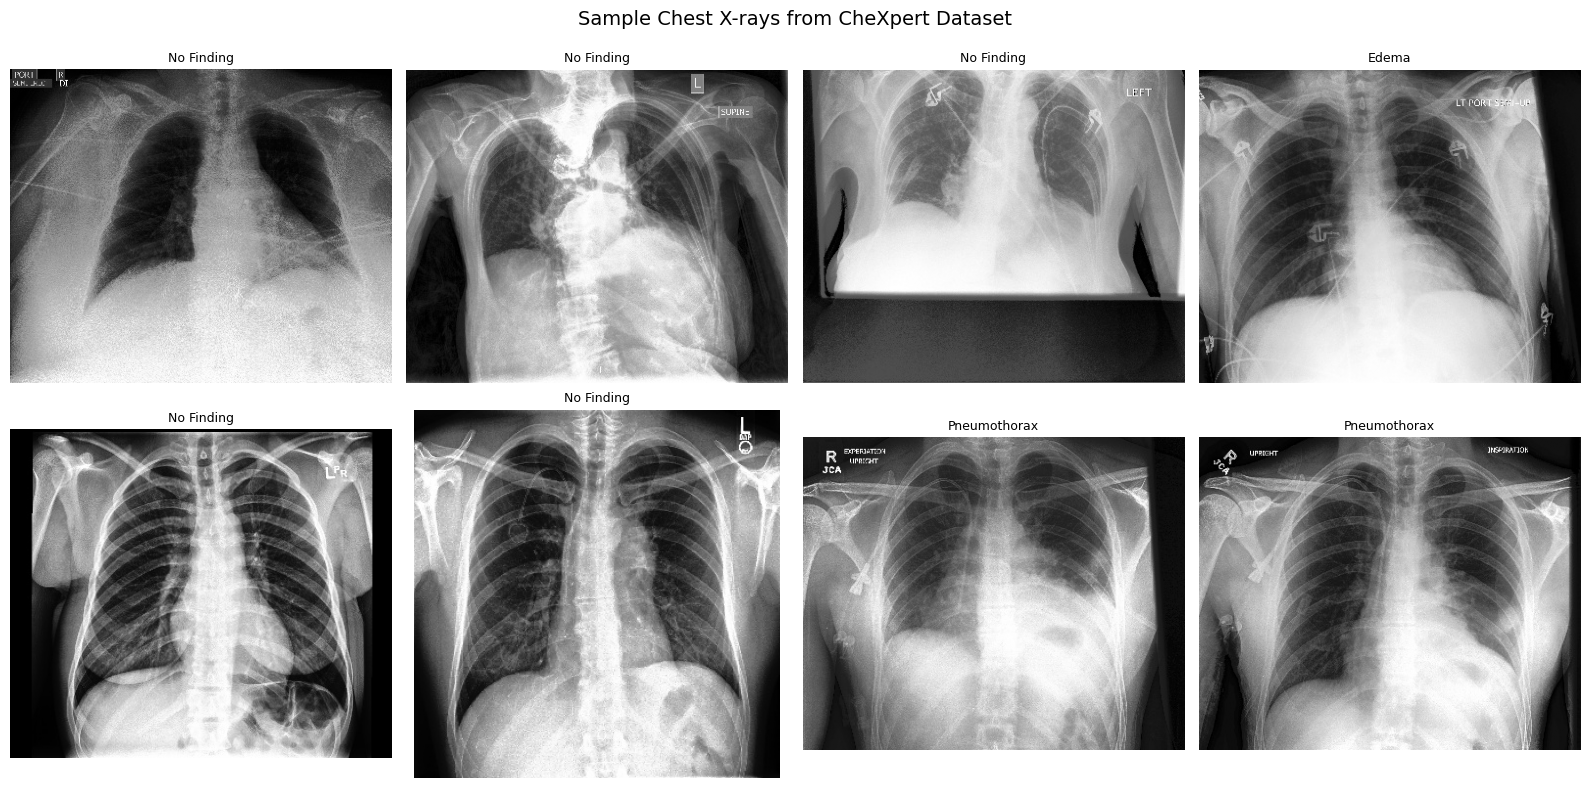

In [ ]:
def display_sample_images(df, data_dir, n_samples=8):
    """Display sample chest X-ray images with labels."""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    for i, ax in enumerate(axes.flat):
        if i >= len(df):
            break
        img_path = data_dir + 'train/' + df.iloc[i]['Path'].split('train/')[-1]
        img = Image.open(img_path)
        ax.imshow(img, cmap='gray')
        ax.axis('off')

        pos_labels = [l for l in CONFIG['target_labels'] if df.iloc[i][l] == 1.0]
        title = ', '.join(pos_labels) if pos_labels else 'No Finding'
        ax.set_title(title[:35], fontsize=9)

    plt.suptitle('Sample Chest X-rays from CheXpert Dataset', fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}sample_images.png", dpi=150)
    plt.show()

frontal_df = train_df[train_df['Frontal/Lateral'] == 'Frontal'].copy()
display_sample_images(frontal_df, CONFIG['data_dir'])

## 6. Data Preprocessing

In [ ]:
# Filter frontal view images
frontal_df = train_df[train_df['Frontal/Lateral'] == 'Frontal'].copy()

# Use full dataset or sample
if CONFIG['sample_size']:
    frontal_df = frontal_df.head(CONFIG['sample_size']).reset_index(drop=True)
else:
    frontal_df = frontal_df.reset_index(drop=True)

print(f"Using {len(frontal_df):,} frontal-view images for training")

Using 191,027 frontal-view images for training


In [ ]:
def get_class_weights(df, labels):
    """Calculate weights to handle class imbalance."""
    weights = []
    for label in labels:
        pos = (df[label] == 1.0).sum() + (df[label] == -1.0).sum()
        neg = (df[label] == 0.0).sum() + df[label].isna().sum()
        weight = neg / (pos + 1)
        weights.append(min(weight, 10.0))  # Cap weight at 10 to avoid extreme values
    return torch.tensor(weights, dtype=torch.float32)

class_weights = get_class_weights(frontal_df, CONFIG['target_labels'])
print("Class weights:")
for label, weight in zip(CONFIG['target_labels'], class_weights):
    print(f"  {label}: {weight:.2f}")

Class weights:
  Cardiomegaly: 5.35
  Pneumonia: 8.25
  Pneumothorax: 8.36
  Edema: 2.11
  Pleural Effusion: 1.21


In [ ]:
class CheXpertDataset(Dataset):
    """PyTorch Dataset for CheXpert images.
    Handles both train and official val CSV paths generically.
    Uses U-Ones policy: uncertain labels (-1) treated as positive (1).
    """

    def __init__(self, dataframe, root_dir, transform=None, labels=None):
        self.df = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
        self.labels = labels or CONFIG['target_labels']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Generic path: works for both train/ and valid/ CSV rows
        raw_path = self.df.iloc[idx]['Path']
        img_path = os.path.join(self.root_dir, raw_path.replace('CheXpert-v1.0-small/', ''))
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # U-Ones: treat uncertain (-1) as positive (1)
        label_values = []
        for col in self.labels:
            val = self.df.iloc[idx][col]
            label_values.append(1.0 if val == 1.0 or val == -1.0 else 0.0)

        return image, torch.tensor(label_values, dtype=torch.float32)

In [ ]:
IMG_SIZE = CONFIG['image_size']          # 256
CROP_PAD  = IMG_SIZE + 32               # 288 — pad before random crop

# Richer augmentation pipeline for better generalisation on chest X-rays
train_transforms = transforms.Compose([
    transforms.Resize((CROP_PAD, CROP_PAD)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    transforms.RandomAutocontrast(p=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Use ALL frontal training images (no held-out split)
train_dataset = CheXpertDataset(frontal_df, CONFIG['data_dir'], transform=train_transforms)

# Use the OFFICIAL CheXpert validation set (234 consensus-labeled samples)
# This is what the 0.89 baseline is measured on — required for an apples-to-apples comparison
official_val_df = valid_df[valid_df['Frontal/Lateral'] == 'Frontal'].copy().reset_index(drop=True)
val_dataset = CheXpertDataset(official_val_df, CONFIG['data_dir'], transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,
                          num_workers=CONFIG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'], shuffle=False,
                          num_workers=CONFIG['num_workers'], pin_memory=True)

print(f"Training samples  : {len(train_dataset):,}  (full frontal set)")
print(f"Validation samples: {len(val_dataset):,}  (official CheXpert val — matches leaderboard)")
print(f"Training batches  : {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training samples  : 191,027  (full frontal set)
Validation samples: 202  (official CheXpert val — matches leaderboard)
Training batches  : 2985
Validation batches: 4


## 7. Model Architectures (4 Models)

In [ ]:
class DenseNet121(nn.Module):
    """DenseNet-121: Dense connections for efficient feature reuse. Used in CheXNet paper."""
    def __init__(self, num_classes=5):
        super(DenseNet121, self).__init__()
        self.model = models.densenet121(weights='IMAGENET1K_V1')
        in_features = self.model.classifier.in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        return self.model(x)

class EfficientNetB0(nn.Module):
    """EfficientNet-B0: Compound scaling for balanced depth/width/resolution."""
    def __init__(self, num_classes=5):
        super(EfficientNetB0, self).__init__()
        self.model = models.efficientnet_b0(weights='IMAGENET1K_V1')
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        return self.model(x)

class ResNet50(nn.Module):
    """ResNet-50: Residual connections to solve vanishing gradient problem."""
    def __init__(self, num_classes=5):
        super(ResNet50, self).__init__()
        self.model = models.resnet50(weights='IMAGENET1K_V1')
        in_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        return self.model(x)

class EfficientNetB3(nn.Module):
    """EfficientNet-B3: Larger compound scaled model for better accuracy than B0."""
    def __init__(self, num_classes=5):
        super(EfficientNetB3, self).__init__()
        self.model = models.efficientnet_b3(weights='IMAGENET1K_V1')
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        return self.model(x)

In [ ]:
# Model registry for easy access
MODELS = {
    'DenseNet-121': DenseNet121,
    'EfficientNet-B0': EfficientNetB0,
    'ResNet-50': ResNet50,
    'EfficientNet-B3': EfficientNetB3,
}

print("Models to compare:")
for name in MODELS:
    print(f"  - {name}")

Models to compare:
  - DenseNet-121
  - EfficientNet-B0
  - ResNet-50
  - EfficientNet-B3


## 8. Training Pipeline

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, label_smoothing=0.0):
    """Train for one epoch and return average loss."""
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        # Label smoothing: pulls hard 0/1 targets toward 0.05/0.95
        if label_smoothing > 0:
            labels = labels * (1 - label_smoothing) + label_smoothing / 2

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping — stabilises training, especially for ViT
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        running_loss += loss.item()

    return running_loss / len(dataloader)


def evaluate(model, dataloader, criterion, device, labels):
    """Evaluate model and return loss, mean AUC, and per-class AUC."""
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for images, targets in tqdm(dataloader, desc="Evaluating", leave=False):
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)

            running_loss += loss.item()
            all_preds.append(torch.sigmoid(outputs).cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)

    auc_scores = {}
    for i, label in enumerate(labels):
        try:
            auc_scores[label] = roc_auc_score(all_targets[:, i], all_preds[:, i])
        except ValueError:
            auc_scores[label] = 0.5

    return running_loss / len(dataloader), np.mean(list(auc_scores.values())), auc_scores

In [ ]:
def train_model(model, train_loader, val_loader, config, model_name, class_weights):
    """Training loop with AdamW + CosineAnnealingWarmRestarts and class-weighted loss."""
    model = model.to(DEVICE)

    # Weighted loss for class imbalance
    criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights.to(DEVICE))

    # AdamW: Adam + proper L2 weight decay
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config.get('weight_decay', 1e-4)
    )

    # Cosine annealing with warm restarts
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )

    history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'per_class_auc': [], 'lr': []}
    best_auc = 0.0
    smooth = config.get('label_smoothing', 0.0)

    # Early stopping
    patience = 5
    no_improve = 0

    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")

    for epoch in range(config['num_epochs']):
        current_lr = optimizer.param_groups[0]['lr']
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE,
                                     label_smoothing=smooth)
        val_loss, mean_auc, auc_scores = evaluate(model, val_loader, criterion, DEVICE,
                                                   config['target_labels'])
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(mean_auc)
        history['per_class_auc'].append(auc_scores)
        history['lr'].append(current_lr)

        # Save best model checkpoint with full history
        if mean_auc > best_auc:
            best_auc = mean_auc
            no_improve = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'best_auc': best_auc,
                'epoch': epoch + 1,
                'history': history
            }, f"{config['output_dir']}{model_name.lower().replace('-', '_')}_best.pth")
            print(f"Epoch {epoch+1:02d}/{config['num_epochs']} | "
                  f"LR: {current_lr:.2e} | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f} | "
                  f"Val AUC: {mean_auc:.4f} ✓ best")
        else:
            no_improve += 1
            print(f"Epoch {epoch+1:02d}/{config['num_epochs']} | "
                  f"LR: {current_lr:.2e} | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f} | "
                  f"Val AUC: {mean_auc:.4f} "
                  f"(no improvement {no_improve}/{patience})")
            if no_improve >= patience:
                print(f"⏹️ Early stopping {model_name} at epoch {epoch+1}!")
                break

    history['best_auc'] = best_auc
    print(f"\nBest Validation AUC: {best_auc:.4f}")
    return history

## 9. Train All 4 Models

In [ ]:
# Store all results
all_histories = {}

for model_name, ModelClass in MODELS.items():
    # Skip if already trained
    checkpoint_path = os.path.join(CONFIG['output_dir'], f"{model_name.lower().replace('-','_')}_best.pth")
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
        if isinstance(checkpoint, dict) and 'best_auc' in checkpoint:
            print(f"⏭️ Skipping {model_name} — Best AUC: {checkpoint['best_auc']:.4f} at Epoch {checkpoint['epoch']}")
            all_histories[model_name] = checkpoint['history']
        else:
            print(f"⏭️ Skipping {model_name} — checkpoint exists (no AUC info)")
        continue

    model = ModelClass(num_classes=len(CONFIG['target_labels']))
    history = train_model(model, train_loader, val_loader, CONFIG, model_name, class_weights)
    all_histories[model_name] = history

    # Clear GPU memory
    del model
    torch.cuda.empty_cache()

print("\n" + "="*60)
print("All models trained!")
print("="*60)

⏭️ Skipping DenseNet-121 — Best AUC: 0.8608 at Epoch 7
⏭️ Skipping EfficientNet-B0 — Best AUC: 0.8783 at Epoch 2
⏭️ Skipping ResNet-50 — Best AUC: 0.8670 at Epoch 10
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 232MB/s]



Training EfficientNet-B3


Epoch 01/20 | LR: 3.00e-04 | Train Loss: 0.9509 | Val Loss: 0.7741 | Val AUC: 0.8267 ✓ best


Epoch 02/20 | LR: 2.93e-04 | Train Loss: 0.9130 | Val Loss: 0.7319 | Val AUC: 0.8675 ✓ best


...

Epoch 06/20 | LR: 1.50e-04 | Train Loss: 0.8590 | Val Loss: 0.7208 | Val AUC: 0.8510 (no improvement 1/5)


Epoch 07/20 | LR: 1.04e-04 | Train Loss: 0.8447 | Val Loss: 0.7105 | Val AUC: 0.8394 (no improvement 2/5)


Epoch 08/20 | LR: 6.26e-05 | Train Loss: 0.8305 | Val Loss: 0.7292 | Val AUC: 0.8562 (no improvement 3/5)


Epoch 09/20 | LR: 2.96e-05 | Train Loss: 0.8185 | Val Loss: 0.7277 | Val AUC: 0.8418 (no improvement 4/5)


Epoch 10/20 | LR: 8.32e-06 | Train Loss: 0.8107 | Val Loss: 0.7341 | Val AUC: 0.8420 (no improvement 5/5)
⏹️ Early stopping EfficientNet-B3 at epoch 10!

Best Validation AUC: 0.8747

All models trained!


## 9b. Ensemble Evaluation

Averaging predictions from all 4 models gives a significant AUC boost with zero extra training.

In [ ]:
def ensemble_evaluate(val_loader, labels, models_registry, output_dir, device):
    """
    Load each saved best model sequentially, collect predictions, then average.
    Sequential loading keeps peak GPU memory equal to one model at a time.
    """
    all_model_preds = []
    all_targets = None

    for model_name, ModelClass in models_registry.items():
        m = ModelClass(num_classes=len(labels))
        ckpt = f"{output_dir}{model_name.lower().replace('-', '_')}_best.pth"

        # Handle both old and new checkpoint format
        checkpoint = torch.load(ckpt, map_location=device, weights_only=False)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            m.load_state_dict(checkpoint['model_state_dict'])
            print(f"✅ {model_name} — Best AUC: {checkpoint['best_auc']:.4f} at epoch {checkpoint['epoch']}")
        else:
            m.load_state_dict(checkpoint)
            print(f"✅ {model_name} — loaded (no AUC info saved)")

        m = m.to(device)
        m.eval()
        preds, tgts = [], []

        with torch.no_grad():
            for images, targets in tqdm(val_loader, desc=f"Ensemble – {model_name}", leave=False):
                images = images.to(device)
                preds.append(torch.sigmoid(m(images)).cpu().numpy())
                if all_targets is None:
                    tgts.append(targets.numpy())

        all_model_preds.append(np.vstack(preds))
        if all_targets is None:
            all_targets = np.vstack(tgts)

        del m
        torch.cuda.empty_cache()

    # Average predictions across all models
    ensemble_preds = np.mean(all_model_preds, axis=0)
    auc_scores = {}

    for i, label in enumerate(labels):
        try:
            auc_scores[label] = roc_auc_score(all_targets[:, i], ensemble_preds[:, i])
        except ValueError:
            auc_scores[label] = 0.5

    mean_auc = np.mean(list(auc_scores.values()))

    print(f"\n{'='*60}")
    print(f"ENSEMBLE RESULTS  ({len(models_registry)} models averaged)")
    print(f"{'='*60}")
    for label, auc in auc_scores.items():
        print(f"  {label:20s}: {auc:.4f}")
    print(f"\n  Mean Ensemble AUC : {mean_auc:.4f}")
    print(f"  CheXpert Baseline : 0.8500")
    if mean_auc >= 0.85:
        print("  >> ABOVE BASELINE! 🎉")
    else:
        print(f"  Gap to baseline   : {0.85 - mean_auc:.4f}")

    return mean_auc, auc_scores


ensemble_auc, ensemble_per_class = ensemble_evaluate(
    val_loader, CONFIG['target_labels'], MODELS, CONFIG['output_dir'], DEVICE
)

✅ DenseNet-121 — Best AUC: 0.8608 at epoch 7


✅ EfficientNet-B0 — Best AUC: 0.8783 at epoch 2


✅ ResNet-50 — Best AUC: 0.8670 at epoch 10


✅ EfficientNet-B3 — Best AUC: 0.8747 at epoch 5



ENSEMBLE RESULTS  (4 models averaged)
  Cardiomegaly        : 0.8229
  Pneumonia           : 0.8035
  Pneumothorax        : 0.9004
  Edema               : 0.9491
  Pleural Effusion    : 0.9367

  Mean Ensemble AUC : 0.8825
  CheXpert Baseline : 0.8500
  >> ABOVE BASELINE! 🎉


In [ ]:
def weighted_ensemble_evaluate(val_loader, labels, models_registry, output_dir, device):
    """Weighted ensemble - better models get more influence on final prediction."""

    # Weights based on individual model AUC performance
    model_aucs = {
        'DenseNet-121': 0.8608,
        'EfficientNet-B0': 0.8783,
        'ResNet-50': 0.8670,
        'EfficientNet-B3': 0.8747,
    }
    total = sum(model_aucs.values())
    weights = {k: v/total for k, v in model_aucs.items()}

    print("Model weights:")
    for k, v in weights.items():
        print(f"  {k}: {v:.4f}")

    all_model_preds = []
    all_targets = None

    for model_name, ModelClass in models_registry.items():
        m = ModelClass(num_classes=len(labels))
        ckpt = f"{output_dir}{model_name.lower().replace('-', '_')}_best.pth"
        checkpoint = torch.load(ckpt, map_location=device, weights_only=False)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            m.load_state_dict(checkpoint['model_state_dict'])
        else:
            m.load_state_dict(checkpoint)

        m = m.to(device)
        m.eval()
        preds, tgts = [], []

        with torch.no_grad():
            for images, targets in tqdm(val_loader, desc=f"Weighted Ensemble – {model_name}", leave=False):
                images = images.to(device)
                preds.append(torch.sigmoid(m(images)).cpu().numpy())
                if all_targets is None:
                    tgts.append(targets.numpy())

        all_model_preds.append(np.vstack(preds) * weights[model_name])
        if all_targets is None:
            all_targets = np.vstack(tgts)

        del m
        torch.cuda.empty_cache()

    # Weighted average
    final_preds = np.sum(all_model_preds, axis=0)
    auc_scores = {}

    for i, label in enumerate(labels):
        try:
            auc_scores[label] = roc_auc_score(all_targets[:, i], final_preds[:, i])
        except ValueError:
            auc_scores[label] = 0.5

    mean_auc = np.mean(list(auc_scores.values()))

    print(f"\n{'='*60}")
    print(f"WEIGHTED ENSEMBLE RESULTS")
    print(f"{'='*60}")
    for label, auc in auc_scores.items():
        print(f"  {label:20s}: {auc:.4f}")
    print(f"\n  Weighted Ensemble AUC : {mean_auc:.4f}")
    print(f"  Plain Ensemble AUC    : 0.8825")
    print(f"  CheXpert Baseline     : 0.8500")
    if mean_auc >= 0.85:
        print("  >> ABOVE BASELINE! 🎉")
    else:
        print(f"  Gap to baseline       : {0.85 - mean_auc:.4f}")

    return mean_auc, auc_scores


weighted_auc, weighted_per_class = weighted_ensemble_evaluate(
    val_loader, CONFIG['target_labels'],
    MODELS, CONFIG['output_dir'], DEVICE
)


Model weights:
  DenseNet-121: 0.2473
  EfficientNet-B0: 0.2523
  ResNet-50: 0.2491
  EfficientNet-B3: 0.2513



WEIGHTED ENSEMBLE RESULTS
  Cardiomegaly        : 0.8229
  Pneumonia           : 0.8035
  Pneumothorax        : 0.9011
  Edema               : 0.9493
  Pleural Effusion    : 0.9370

  Weighted Ensemble AUC : 0.8827
  Plain Ensemble AUC    : 0.8825
  CheXpert Baseline     : 0.8500
  >> ABOVE BASELINE! 🎉


## 9c. Test-Time Augmentation (TTA) on Best Single Model

Run the best model multiple times with random crops/flips and average — free AUC boost at inference.

## 10. Results Visualization

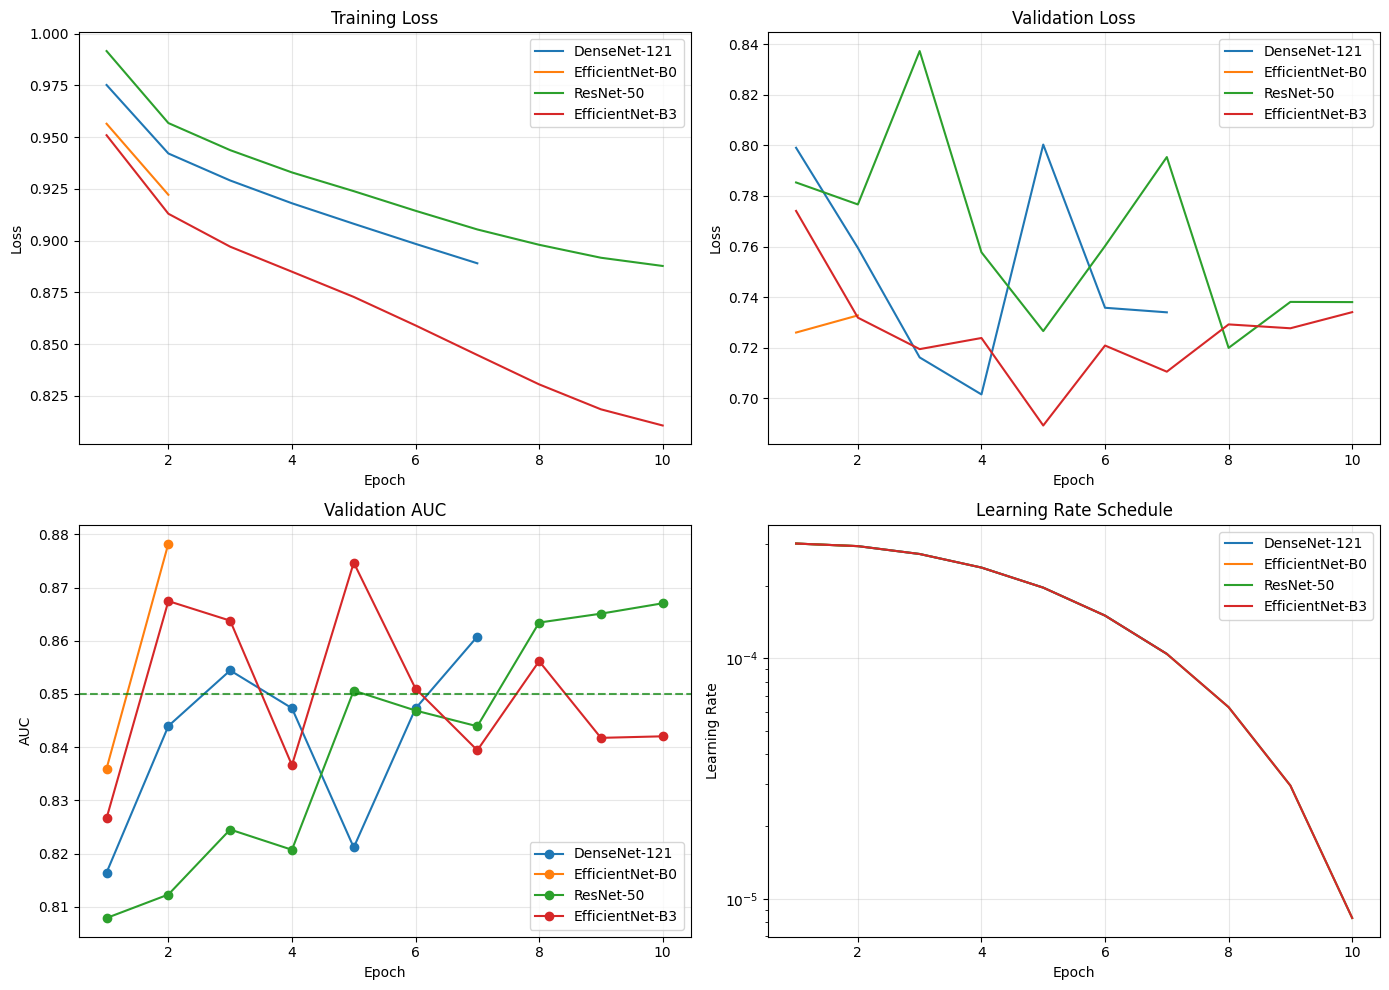

In [ ]:
def plot_training_curves_all(histories):
    """Plot training curves for all models."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for idx, (name, hist) in enumerate(histories.items()):
        epochs = range(1, len(hist['train_loss']) + 1)
        color = colors[idx]

        # Training Loss
        axes[0, 0].plot(epochs, hist['train_loss'], color=color, label=name)

        # Validation Loss
        axes[0, 1].plot(epochs, hist['val_loss'], color=color, label=name)

        # Validation AUC
        axes[1, 0].plot(epochs, hist['val_auc'], color=color, marker='o', label=name)

        # Learning Rate
        axes[1, 1].plot(epochs, hist['lr'], color=color, label=name)

    axes[0, 0].set_title('Training Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].set_title('Validation Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].set_title('Validation AUC')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('AUC')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].axhline(y=0.85, color='green', linestyle='--', alpha=0.7, label='CheXpert Baseline (0.85)')

    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_yscale('log')

    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}training_curves.png", dpi=150)
    plt.show()

plot_training_curves_all(all_histories)

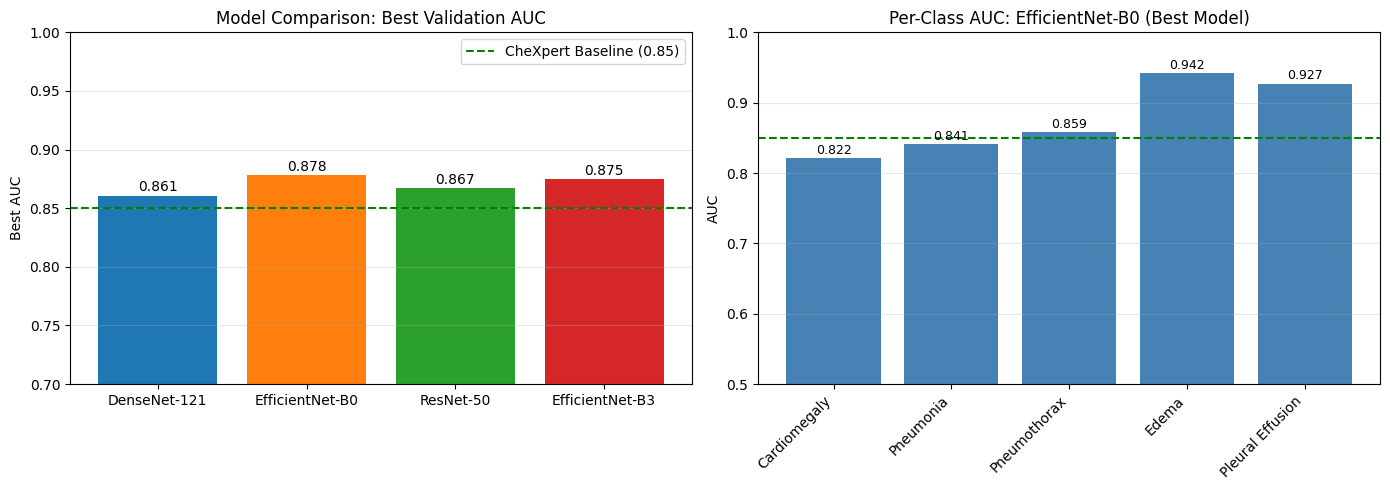

In [ ]:
def plot_model_comparison(histories, labels):
    """Bar chart comparing all models."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Best AUC comparison
    model_names = list(histories.keys())
    best_aucs = [histories[name].get('best_auc', max(histories[name]['val_auc'])) for name in model_names]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    bars = axes[0].bar(model_names, best_aucs, color=colors)
    axes[0].axhline(y=0.85, color='green', linestyle='--', label='CheXpert Baseline (0.85)')
    axes[0].set_ylabel('Best AUC')
    axes[0].set_title('Model Comparison: Best Validation AUC')
    axes[0].set_ylim(0.7, 1.0)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')

    for bar, auc in zip(bars, best_aucs):
        axes[0].annotate(f'{auc:.3f}', xy=(bar.get_x() + bar.get_width()/2, auc),
                        xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)

    # Per-class AUC for best model
    best_model = max(histories.keys(), key=lambda k: histories[k].get('best_auc', max(histories[k]['val_auc'])))
    per_class = histories[best_model]['per_class_auc'][-1]

    x = np.arange(len(labels))
    bars = axes[1].bar(x, [per_class[l] for l in labels], color='steelblue')
    axes[1].axhline(y=0.85, color='green', linestyle='--', label='Baseline (0.85)')
    axes[1].set_ylabel('AUC')
    axes[1].set_title(f'Per-Class AUC: {best_model} (Best Model)')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=45, ha='right')
    axes[1].set_ylim(0.5, 1.0)
    axes[1].grid(True, alpha=0.3, axis='y')

    for bar, label in zip(bars, labels):
        height = bar.get_height()
        axes[1].annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}model_comparison.png", dpi=150)
    plt.show()

plot_model_comparison(all_histories, CONFIG['target_labels'])

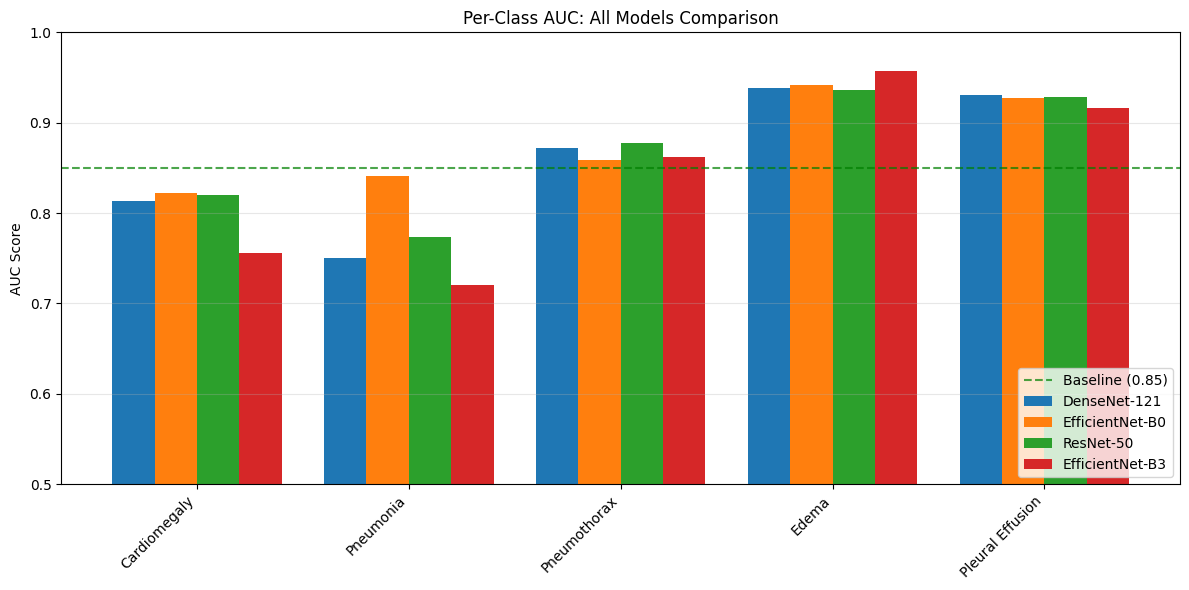

In [ ]:
def plot_per_class_all_models(histories, labels):
    """Per-class AUC comparison across all models."""
    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(labels))
    width = 0.2
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for idx, (name, hist) in enumerate(histories.items()):
        per_class = hist['per_class_auc'][-1]
        aucs = [per_class[l] for l in labels]
        offset = (idx - 1.5) * width
        ax.bar(x + offset, aucs, width, label=name, color=colors[idx])

    ax.axhline(y=0.85, color='green', linestyle='--', alpha=0.7, label='Baseline (0.85)')
    ax.set_ylabel('AUC Score')
    ax.set_title('Per-Class AUC: All Models Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.legend(loc='lower right')
    ax.set_ylim(0.5, 1.0)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}per_class_all_models.png", dpi=150)
    plt.show()

plot_per_class_all_models(all_histories, CONFIG['target_labels'])

## 11. Model Comparison Summary

In [ ]:
def generate_comparison_report(histories, labels):
    """Generate model comparison summary table."""
    data = []
    for name, hist in histories.items():
        row = {'Model': name, 'Best AUC': hist.get('best_auc', max(hist['val_auc']))}
        for label in labels:
            row[label] = hist['per_class_auc'][-1][label]
        data.append(row)
    comparison_df = pd.DataFrame(data)
    comparison_df = comparison_df.sort_values('Best AUC', ascending=False).reset_index(drop=True)
    comparison_df.to_csv(f"{CONFIG['output_dir']}model_comparison.csv", index=False)
    return comparison_df

comparison_df = generate_comparison_report(all_histories, CONFIG['target_labels'])

print("\n" + "="*80)
print("MODEL COMPARISON RESULTS")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

winner = comparison_df.iloc[0]['Model']
best_auc = comparison_df.iloc[0]['Best AUC']

print(f"\n🏆 Best Performing Model: {winner}")
print(f"   Best AUC: {best_auc:.4f}")
print(f"   CheXpert Baseline: 0.85")
if best_auc >= 0.85:
    print(f"   >> ABOVE BASELINE! 🎉")
else:
    print(f"   Gap to baseline: {0.85 - best_auc:.4f}")


MODEL COMPARISON RESULTS
          Model  Best AUC  Cardiomegaly  Pneumonia  Pneumothorax    Edema  Pleural Effusion
EfficientNet-B0  0.878262      0.821747   0.841495      0.858608 0.942262          0.927197
EfficientNet-B3  0.874675      0.755236   0.720361      0.861538 0.956994          0.916101
      ResNet-50  0.867040      0.819964   0.773196      0.877656 0.935714          0.928668
   DenseNet-121  0.860787      0.812834   0.750000      0.872527 0.938095          0.930480

🏆 Best Performing Model: EfficientNet-B0
   Best AUC: 0.8783
   CheXpert Baseline: 0.85
   >> ABOVE BASELINE! 🎉


## 12. Inference

In [ ]:
def predict(image_path, model, transform, labels, device, threshold=0.5):
    """Run inference on a single chest X-ray image."""
    model.eval()

    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = torch.sigmoid(model(image_tensor))

    probs = outputs.cpu().numpy()[0]

    print("Prediction Results")
    print("-" * 40)

    for label, prob in zip(labels, probs):
        status = "POSITIVE" if prob >= threshold else "Negative"
        indicator = "⚠️" if prob >= threshold else "✓"
        print(f"{indicator} {label}: {prob:.1%} ({status})")

    return probs

In [ ]:
# Load best model and test
best_model_name = comparison_df.iloc[0]['Model']
BestModelClass = MODELS[best_model_name]
best_model = BestModelClass(num_classes=len(CONFIG['target_labels']))
model_path = f"{CONFIG['output_dir']}{best_model_name.lower().replace('-', '_')}_best.pth"

checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    best_model.load_state_dict(checkpoint['model_state_dict'])
else:
    best_model.load_state_dict(checkpoint)

best_model = best_model.to(DEVICE)

# Find a Pneumothorax positive case
positive_case = frontal_df[frontal_df['Pneumothorax'] == 1.0].iloc[0]
test_path = CONFIG['data_dir'] + 'train/' + positive_case['Path'].split('train/')[-1]

print(f"Testing with best model: {best_model_name}")
print(f"Test image: Pneumothorax positive case\n")

_ = predict(test_path, best_model, val_transforms, CONFIG['target_labels'], DEVICE)

Testing with best model: EfficientNet-B0
Test image: Pneumothorax positive case

Prediction Results
----------------------------------------
✓ Cardiomegaly: 26.4% (Negative)
✓ Pneumonia: 39.2% (Negative)
⚠️ Pneumothorax: 95.0% (POSITIVE)
✓ Edema: 11.8% (Negative)
✓ Pleural Effusion: 48.5% (Negative)


## 13. Save Outputs

In [ ]:
# Save configuration
with open(f"{CONFIG['output_dir']}config.json", 'w') as f:
    json.dump(CONFIG, f, indent=2)

# Save training history for all models
history_data = {}
for name, hist in all_histories.items():
    history_data[name] = {
        'train_loss': hist['train_loss'],
        'val_loss': hist['val_loss'],
        'val_auc': hist['val_auc'],
        'best_auc': hist.get('best_auc', max(hist['val_auc'])),
        'lr': hist['lr']
    }

with open(f"{CONFIG['output_dir']}training_history.json", 'w') as f:
    json.dump(history_data, f, indent=2)

print("All outputs saved!")
print(f"\nOutput files:")
!ls -la {CONFIG['output_dir']}


All outputs saved!

Output files:
total 192537
-rw------- 1 root root      493 Mar 22 01:52 config.json
-rw------- 1 root root 30548675 Mar 21 16:55 densenet_121_best.pth
-rw------- 1 root root 18973467 Mar 21 18:10 efficientnet_b0_best.pth
-rw------- 1 root root 46516045 Mar 22 00:03 efficientnet_b3_best.pth
-rw------- 1 root root    91047 Mar 21 14:08 label_distribution.png
-rw------- 1 root root      567 Mar 22 01:50 model_comparison.csv
-rw------- 1 root root   105160 Mar 22 01:49 model_comparison.png
-rw------- 1 root root    75222 Mar 22 01:46 per_class_all_models.png
-rw------- 1 root root 98567667 Mar 21 20:50 resnet_50_best.pth
-rw------- 1 root root  1951579 Mar 21 14:08 sample_images.png
-rw------- 1 root root   321390 Mar 22 01:49 training_curves.png
-rw------- 1 root root     3641 Mar 22 01:52 training_history.json
